# Model Evaluation and Explainability

This notebook performs the final evaluation and explainability analysis of
the selected forest-fire burned-area prediction model.

The final model was selected after comparing multiple regression algorithms,
hyperparameter-tuned models, a severity-aware two-stage architecture, and
an ensemble approach.

The selected model is a weighted ensemble consisting of:

- 70% HistGradientBoosting Regressor
- 30% Random Forest Regressor

The final model achieved a testing R² of **0.2302**, MAE of **0.8328**, and
RMSE of **1.0421** on the log-transformed burned-area target.

This notebook focuses on evaluating generalisation performance, analysing
prediction errors, interpreting feature contributions, and preparing the
final model for integration into the Flask-based prediction system.

In [1]:
# IMPORT LIBRARIES

import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.ensemble import (
    HistGradientBoostingRegressor,
    RandomForestRegressor
)

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
# LOAD PROCESSED DATA

PROJECT_ROOT = Path("../../")

PROCESSED_DIR = PROJECT_ROOT / "dataset" / "processed"

X_train = pd.read_csv(PROCESSED_DIR / "X_train.csv")
X_test = pd.read_csv(PROCESSED_DIR / "X_test.csv")

y_train = pd.read_csv(
    PROCESSED_DIR / "y_train.csv"
).squeeze("columns")

y_test = pd.read_csv(
    PROCESSED_DIR / "y_test.csv"
).squeeze("columns")

print("Processed data loaded successfully.")

print("\nTraining data:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTesting data:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Processed data loaded successfully.

Training data:
X_train: (9042, 44)
y_train: (9042,)

Testing data:
X_test: (2261, 44)
y_test: (2261,)


In [3]:
# VERIFY FEATURE CONSISTENCY

print("Training features:", X_train.shape[1])
print("Testing features :", X_test.shape[1])

print(
    "\nFeature order identical:",
    list(X_train.columns) == list(X_test.columns)
)

print(
    "Missing values in X_train:",
    X_train.isna().sum().sum()
)

print(
    "Missing values in X_test:",
    X_test.isna().sum().sum()
)

assert list(X_train.columns) == list(X_test.columns)
assert X_train.isna().sum().sum() == 0
assert X_test.isna().sum().sum() == 0

print("\nFinal data validation passed.")

Training features: 44
Testing features : 44

Feature order identical: True
Missing values in X_train: 0
Missing values in X_test: 0

Final data validation passed.


In [4]:
# FINAL ENSEMBLE MODEL

# HistGradientBoosting component
final_hist_model = HistGradientBoostingRegressor(
    min_samples_leaf=30,
    max_leaf_nodes=31,
    max_iter=100,
    max_depth=10,
    learning_rate=0.05,
    l2_regularization=1.0,
    random_state=42
)

# Random Forest component
final_rf_model = RandomForestRegressor(
    n_estimators=500,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features=0.7,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

# Train on the complete training dataset
final_hist_model.fit(
    X_train,
    y_train
)

final_rf_model.fit(
    X_train,
    y_train
)

print("Final ensemble models trained successfully.")

Final ensemble models trained successfully.


### Actual vs Predicted Analysis

In [5]:
# GENERATE FINAL TEST PREDICTIONS

hist_test_predictions = final_hist_model.predict(X_test)

rf_test_predictions = final_rf_model.predict(X_test)

# Final ensemble weights
hist_weight = 0.70
rf_weight = 0.30

final_test_predictions = (
    hist_weight * hist_test_predictions
    + rf_weight * rf_test_predictions
)

print("Final predictions generated.")

print("\nPrediction shape:")
print(final_test_predictions.shape)

print("\nPrediction range:")
print(
    "Minimum:",
    round(final_test_predictions.min(), 4)
)

print(
    "Maximum:",
    round(final_test_predictions.max(), 4)
)

Final predictions generated.

Prediction shape:
(2261,)

Prediction range:
Minimum: 4.1188
Maximum: 7.2802


In [6]:
# FINAL MODEL PERFORMANCE

final_r2 = r2_score(
    y_test,
    final_test_predictions
)

final_mae = mean_absolute_error(
    y_test,
    final_test_predictions
)

final_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        final_test_predictions
    )
)

print("=" * 55)
print("FINAL ENSEMBLE PERFORMANCE")
print("=" * 55)

print(f"Test R²   : {final_r2:.4f}")
print(f"Test MAE  : {final_mae:.4f}")
print(f"Test RMSE : {final_rmse:.4f}")

FINAL ENSEMBLE PERFORMANCE
Test R²   : 0.2302
Test MAE  : 0.8328
Test RMSE : 1.0421


In [7]:
# VERIFY FINAL MODEL RESULT

expected_r2 = 0.2302
expected_mae = 0.8328
expected_rmse = 1.0421

print("Recorded vs newly calculated performance")
print("=" * 55)

print(
    f"R²   : recorded={expected_r2:.4f} | "
    f"calculated={final_r2:.4f}"
)

print(
    f"MAE  : recorded={expected_mae:.4f} | "
    f"calculated={final_mae:.4f}"
)

print(
    f"RMSE : recorded={expected_rmse:.4f} | "
    f"calculated={final_rmse:.4f}"
)

Recorded vs newly calculated performance
R²   : recorded=0.2302 | calculated=0.2302
MAE  : recorded=0.8328 | calculated=0.8328
RMSE : recorded=1.0421 | calculated=1.0421


In [ ]:
# CONVERT PREDICTIONS BACK TO BURNED AREA (HECTARES)

actual_burned_area_ha = np.expm1(y_test)
predicted_burned_area_ha = np.expm1(final_test_predictions)

print("Actual burned-area range:")
print(
    round(actual_burned_area_ha.min(), 2),
    "to",
    round(actual_burned_area_ha.max(), 2),
    "ha"
)

print("\nPredicted burned-area range:")
print(
    round(predicted_burned_area_ha.min(), 2),
    "to",
    round(predicted_burned_area_ha.max(), 2),
    "ha"
)

Actual burned-area range:
30.0 to 23078.0 ha

Predicted burned-area range:
60.48 to 1450.34 ha


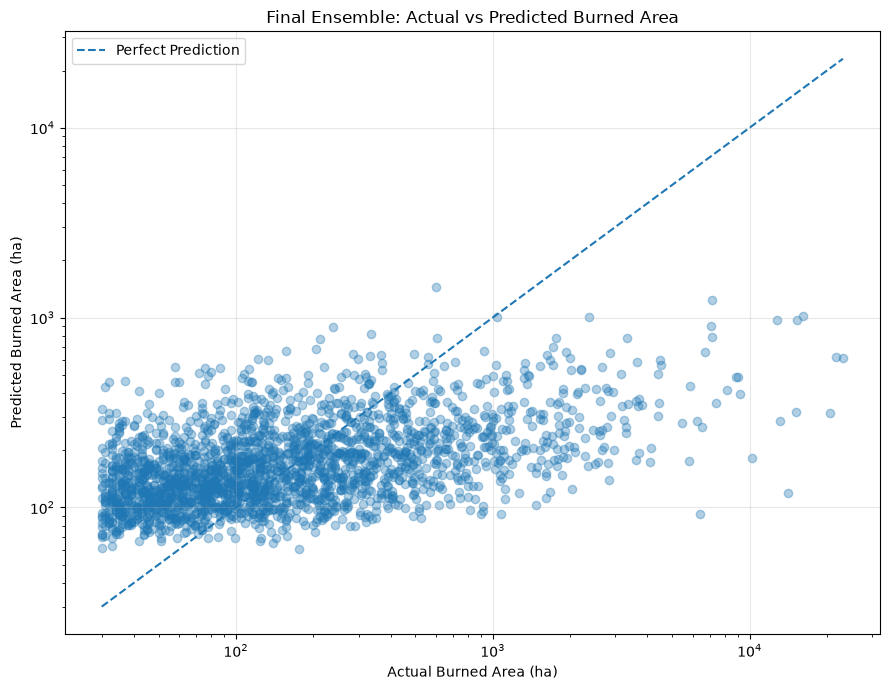

In [9]:
# ACTUAL VS PREDICTED BURNED AREA

plt.figure(figsize=(9, 7))

plt.scatter(
    actual_burned_area_ha,
    predicted_burned_area_ha,
    alpha=0.35
)

min_value = min(
    actual_burned_area_ha.min(),
    predicted_burned_area_ha.min()
)

max_value = max(
    actual_burned_area_ha.max(),
    predicted_burned_area_ha.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    label="Perfect Prediction"
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Actual Burned Area (ha)")
plt.ylabel("Predicted Burned Area (ha)")
plt.title("Final Ensemble: Actual vs Predicted Burned Area")

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Actual vs Predicted Burned Area

The final ensemble predictions were transformed from the logarithmic target
scale back into hectares using the inverse transformation:

    burned_area = exp(prediction) - 1

The actual testing observations range from approximately **30 ha to
23,078 ha**, while the model predictions range from approximately
**60.48 ha to 1,450.34 ha**.

The actual-versus-predicted plot shows that predictions are reasonably
concentrated around the general trend for lower and moderate burned-area
events. However, the model increasingly underpredicts observations with
very large burned areas.

This behaviour indicates that the final ensemble is conservative when
predicting extreme wildfire events. The model captures the general
relationship between the input variables and burned area but has limited
ability to reproduce the magnitude of rare extreme events.

This finding is consistent with the characteristics of the dataset, where
extreme burned-area observations are relatively uncommon and exhibit high
variability. Consequently, the model provides more reliable estimates for
the common range of fire sizes than for exceptionally large wildfire
events.

The analysis also demonstrates why evaluation using multiple metrics and
visual diagnostics is important rather than relying solely on the overall
R² score.

### Residual and Error Analysis

In [10]:
# RESIDUAL / ERROR ANALYSIS

residuals = y_test - final_test_predictions

error_analysis = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": final_test_predictions,
    "Residual": residuals.values,
    "Absolute_Error": np.abs(residuals.values)
})

print("Residual analysis created.")

print("\nResidual statistics:")
print(error_analysis["Residual"].describe())

Residual analysis created.

Residual statistics:
count    2261.000000
mean       -0.047465
std         1.041293
min        -2.631357
25%        -0.803190
50%        -0.213890
75%         0.587154
max         4.774493
Name: Residual, dtype: float64


In [11]:
# PREDICTION BIAS ANALYSIS

mean_error = residuals.mean()
median_error = residuals.median()
mae = np.abs(residuals).mean()

overpredictions = (residuals < 0).sum()
underpredictions = (residuals > 0).sum()

print("=" * 55)
print("FINAL ENSEMBLE — PREDICTION BIAS ANALYSIS")
print("=" * 55)

print(f"Mean Error              : {mean_error:.4f}")
print(f"Median Error            : {median_error:.4f}")
print(f"Mean Absolute Error     : {mae:.4f}")

print(f"\nOverpredictions         : {overpredictions}")
print(f"Underpredictions        : {underpredictions}")

FINAL ENSEMBLE — PREDICTION BIAS ANALYSIS
Mean Error              : -0.0475
Median Error            : -0.2139
Mean Absolute Error     : 0.8328

Overpredictions         : 1313
Underpredictions        : 948


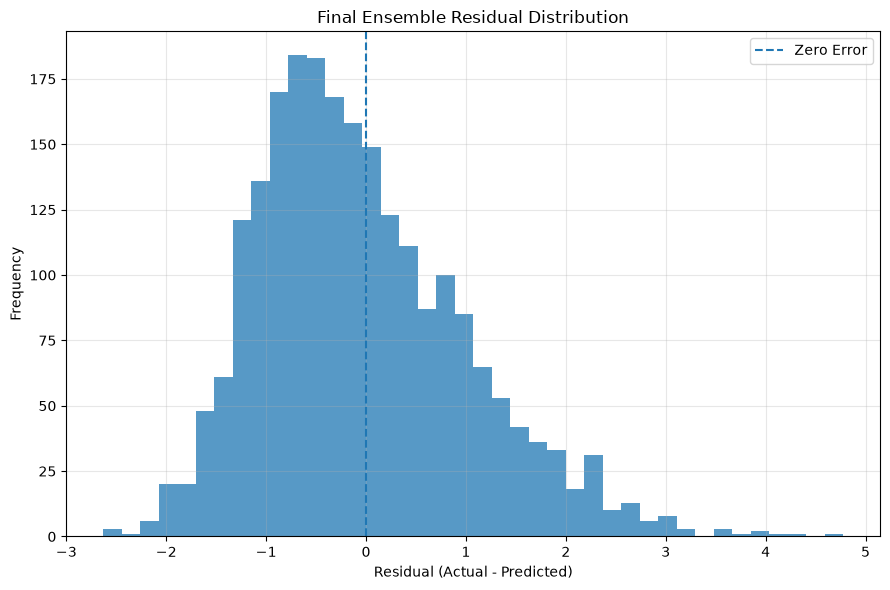

In [12]:
# RESIDUAL DISTRIBUTION

plt.figure(figsize=(9, 6))

plt.hist(
    residuals,
    bins=40,
    alpha=0.75
)

plt.axvline(
    0,
    linestyle="--",
    label="Zero Error"
)

plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Frequency")
plt.title("Final Ensemble Residual Distribution")

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

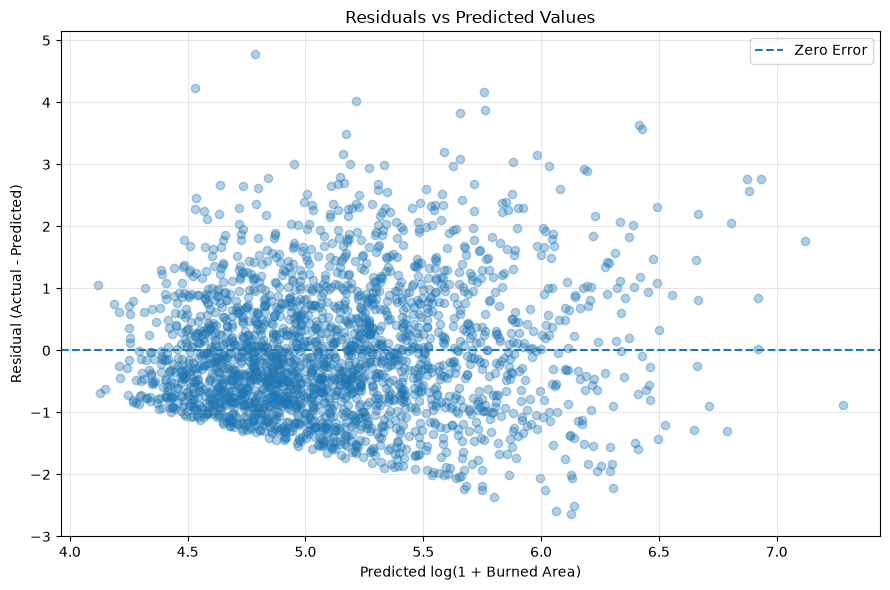

In [13]:
# RESIDUALS VS PREDICTED VALUES

plt.figure(figsize=(9, 6))

plt.scatter(
    final_test_predictions,
    residuals,
    alpha=0.35
)

plt.axhline(
    0,
    linestyle="--",
    label="Zero Error"
)

plt.xlabel("Predicted log(1 + Burned Area)")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residuals vs Predicted Values")

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Residual and Prediction Bias Analysis

Residual analysis was performed using the definition:

    Residual = Actual - Predicted

The final ensemble produced a mean residual of **−0.0475** and a median
residual of **−0.2139** on the log-transformed target scale. The mean
residual being close to zero indicates that the model has relatively little
overall systematic bias.

The model produced **1,313 overpredictions** and **948 underpredictions**
among the 2,261 testing observations. The negative median residual
indicates a slight tendency toward overprediction for the typical
observation.

The residual distribution is asymmetric and contains a longer positive
tail. This indicates that although the model is reasonably balanced overall,
there are individual observations for which the actual burned area is
substantially larger than the predicted value.

The residual-versus-predicted plot also shows increasing residual
variability as the predicted target increases. This suggests that
prediction uncertainty becomes greater for larger burned-area events.

Overall, the residual analysis indicates that the final ensemble has low
overall systematic bias but struggles with highly variable and extreme
fire events. This behaviour is consistent with the earlier actual-versus-
predicted analysis and the strongly skewed nature of the burned-area
target.

### Error Analysis by Burned-Area Range

In [14]:
# ERROR ANALYSIS BY BURNED-AREA RANGE

range_analysis = pd.DataFrame({
    "actual_ha": actual_burned_area_ha,
    "predicted_ha": predicted_burned_area_ha
})

def classify_burned_area(area):
    if area <= 100:
        return "30–100 ha"
    elif area <= 500:
        return "101–500 ha"
    elif area <= 5000:
        return "501–5,000 ha"
    elif area <= 10000:
        return "5,001–10,000 ha"
    else:
        return ">10,000 ha"

range_analysis["burned_area_range"] = (
    range_analysis["actual_ha"]
    .apply(classify_burned_area)
)

range_analysis["error_ha"] = (
    range_analysis["actual_ha"]
    - range_analysis["predicted_ha"]
)

range_analysis["absolute_error_ha"] = (
    np.abs(range_analysis["error_ha"])
)

print("Burned-area range classification completed.")

Burned-area range classification completed.


In [15]:
# RANGE-BASED ERROR SUMMARY

range_summary = (
    range_analysis
    .groupby("burned_area_range")
    .agg(
        records=("actual_ha", "count"),
        mean_actual_ha=("actual_ha", "mean"),
        mean_predicted_ha=("predicted_ha", "mean"),
        mean_error_ha=("error_ha", "mean"),
        MAE_ha=("absolute_error_ha", "mean")
    )
    .reset_index()
)

range_order = [
    "30–100 ha",
    "101–500 ha",
    "501–5,000 ha",
    "5,001–10,000 ha",
    ">10,000 ha"
]

range_summary["burned_area_range"] = pd.Categorical(
    range_summary["burned_area_range"],
    categories=range_order,
    ordered=True
)

range_summary = (
    range_summary
    .sort_values("burned_area_range")
    .reset_index(drop=True)
)

display(range_summary.round(2))

,burned_area_range,records,mean_actual_ha,mean_predicted_ha,mean_error_ha,MAE_ha
0,30–100 ha,918,58.14,146.91,-88.77,89.00
1,101–500 ha,971,222.15,197.75,24.40,103.68
2,"501–5,000 ha",347,1301.07,278.86,1022.21,1028.49
3,"5,001–10,000 ha",15,7128.47,483.59,6644.88,6644.88
4,">10,000 ha",10,16222.80,541.02,15681.78,15681.78


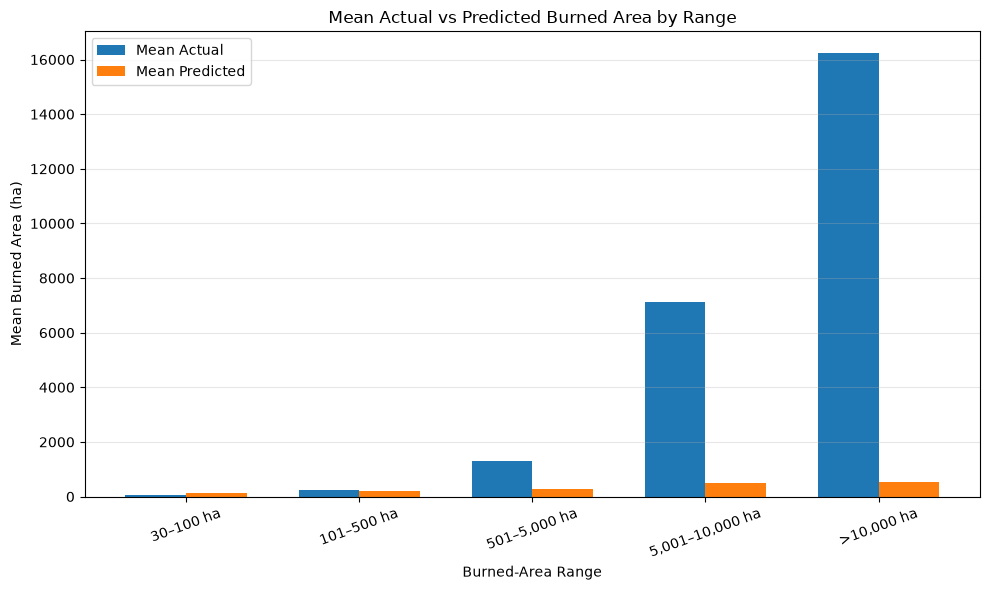

In [16]:
# ACTUAL VS PREDICTED BY BURNED-AREA RANGE

x = np.arange(len(range_summary))

width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    range_summary["mean_actual_ha"],
    width,
    label="Mean Actual"
)

plt.bar(
    x + width / 2,
    range_summary["mean_predicted_ha"],
    width,
    label="Mean Predicted"
)

plt.xticks(
    x,
    range_summary["burned_area_range"],
    rotation=20
)

plt.xlabel("Burned-Area Range")
plt.ylabel("Mean Burned Area (ha)")
plt.title("Mean Actual vs Predicted Burned Area by Range")

plt.legend()
plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

## Error Analysis by Burned-Area Range

The final ensemble was further evaluated by grouping testing observations
according to their actual burned-area magnitude.

The analysis shows that model performance varies substantially across fire
severity ranges.

For fires between **30–100 ha**, the model tends to overpredict the burned
area, with a mean actual value of 58.14 ha and a mean predicted value of
146.91 ha.

The **101–500 ha** range provides the most balanced results, with a mean
actual burned area of 222.15 ha compared with a mean prediction of
197.75 ha. This range also contains 971 of the 2,261 testing observations,
making it one of the most representative regions of the test dataset.

For larger fires, the model increasingly underpredicts the magnitude of
the burned area. For the **501–5,000 ha** range, the mean actual burned
area is 1,301.07 ha, while the mean prediction is only 278.86 ha.

The underprediction becomes particularly pronounced for extreme events.
The 5,001–10,000 ha category has a mean actual burned area of 7,128.47 ha
but a mean prediction of only 483.59 ha. Similarly, observations above
10,000 ha have a mean actual burned area of 16,222.80 ha compared with a
mean prediction of 541.02 ha.

However, these extreme categories contain only 15 and 10 observations,
respectively. Therefore, the model has relatively little training
information from which to learn the behaviour and magnitude of such rare
events.

Overall, the analysis demonstrates that the final ensemble performs more
reliably for the common and moderate burned-area ranges but has substantial
difficulty estimating the magnitude of rare extreme fires. This represents
an important limitation of the current dataset and should be considered
when interpreting predictions produced by the system.

### Permutation Feature Importance

In [21]:
# PERMUTATION FEATURE IMPORTANCE — FINAL ENSEMBLE

from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.inspection import permutation_importance


class FinalEnsemble(BaseEstimator, RegressorMixin):

    def __init__(self, hist_model, rf_model):
        self.hist_model = hist_model
        self.rf_model = rf_model

    def fit(self, X, y):
        # Models are already trained.
        # No retraining is required here.
        return self

    def predict(self, X):

        hist_pred = self.hist_model.predict(X)
        rf_pred = self.rf_model.predict(X)

        return (
            0.70 * hist_pred
            + 0.30 * rf_pred
        )


print("Creating final ensemble estimator...")

final_ensemble_estimator = FinalEnsemble(
    hist_model=final_hist_model,
    rf_model=final_rf_model
)

print("Calculating permutation feature importance...")

permutation_result = permutation_importance(
    final_ensemble_estimator,
    X_test,
    y_test,
    scoring="r2",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

print("Permutation importance calculation completed.")

Creating final ensemble estimator...
Calculating permutation feature importance...
Permutation importance calculation completed.


In [22]:
# PERMUTATION IMPORTANCE TABLE


permutation_importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance_Mean": permutation_result.importances_mean,
    "Importance_STD": permutation_result.importances_std
})

permutation_importance_df = (
    permutation_importance_df
    .sort_values(
        "Importance_Mean",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    permutation_importance_df.round(4)
)

,Feature,Importance_Mean,Importance_STD
0,relative_humidity,0.0665,0.0039
1,year,0.0483,0.0055
2,longitude,0.0409,0.0062
3,latitude,0.0400,0.0021
4,day_of_year_cos,0.0264,0.0055
5,wind_speed,0.0220,0.0029
6,lc_agriculture,0.0204,0.0037
7,ndvi,0.0197,0.0026
8,temperature_c,0.0187,0.0028
9,population,0.0131,0.0022


In [23]:
# TOP 15 FEATURES

top_features = (
    permutation_importance_df
    .head(15)
    .copy()
)

display(
    top_features.round(4)
)

,Feature,Importance_Mean,Importance_STD
0,relative_humidity,0.0665,0.0039
1,year,0.0483,0.0055
2,longitude,0.0409,0.0062
3,latitude,0.0400,0.0021
4,day_of_year_cos,0.0264,0.0055
5,wind_speed,0.0220,0.0029
6,lc_agriculture,0.0204,0.0037
7,ndvi,0.0197,0.0026
8,temperature_c,0.0187,0.0028
9,population,0.0131,0.0022


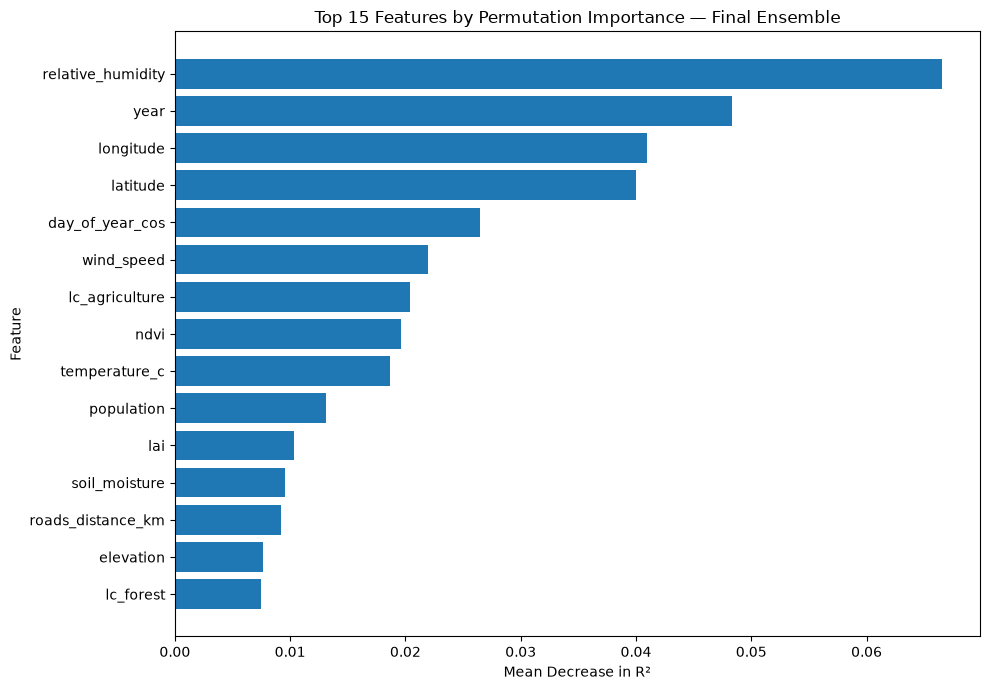

In [24]:
# TOP 15 PERMUTATION FEATURE IMPORTANCES


plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance_Mean"][::-1]
)

plt.xlabel("Mean Decrease in R²")
plt.ylabel("Feature")
plt.title(
    "Top 15 Features by Permutation Importance — Final Ensemble"
)

plt.tight_layout()
plt.show()

## Final Ensemble Permutation Feature Importance

Permutation feature importance was calculated for the final 70:30
HistGradientBoosting–Random Forest ensemble to identify the variables
that contributed most strongly to predictive performance.

The results show that **relative humidity** was the most influential
feature, with a mean decrease in R² of 0.0665 when the feature was
permuted. This was followed by **year (0.0483)**, **longitude (0.0409)**,
and **latitude (0.0400)**. The strong contribution of latitude and
longitude indicates that the model captures important spatial patterns
within the dataset.

The cyclical temporal variable **day_of_year_cos (0.0264)** was also
among the most influential predictors, indicating that seasonal
variation contributes to burned-area prediction. Meteorological
variables including **wind speed (0.0220)** and **temperature (0.0187)**
also provided meaningful predictive information.

Vegetation and land-cover variables, including **lc_agriculture (0.0204)**
and **ndvi (0.0197)**, were also important. Additional environmental and
geographical variables such as population, LAI, soil moisture, road
distance, elevation and forest land cover contributed smaller but
measurable amounts of predictive information.

Overall, the permutation analysis demonstrates that the final ensemble
does not depend on a single predictor. Instead, it combines
**meteorological, geographical, vegetation, land-cover and temporal
information** to estimate burned area. The results represent predictive
importance rather than causal relationships; therefore, a high feature
importance should not be interpreted as evidence that the feature
directly causes larger burned areas.

Features associated with missing-value indicators and several low-impact
temporal or directional variables produced importance values close to
zero, suggesting that they provide limited additional predictive
information for the final model.

In [25]:
# SHAP EXPLAINABILITY — FINAL ENSEMBLE

import shap
import numpy as np

print("Creating SHAP explainer...")

# Use a representative background sample
background = X_train.sample(
    n=min(100, len(X_train)),
    random_state=42
)

def final_ensemble_predict(X):
    hist_pred = final_hist_model.predict(X)
    rf_pred = final_rf_model.predict(X)

    return (
        0.70 * hist_pred
        + 0.30 * rf_pred
    )

explainer = shap.Explainer(
    final_ensemble_predict,
    background
)

print("SHAP explainer created successfully.")

Creating SHAP explainer...
SHAP explainer created successfully.


In [26]:
# CALCULATE SHAP VALUES

X_shap = X_test.sample(
    n=min(300, len(X_test)),
    random_state=42
)

print("Calculating SHAP values...")

shap_values = explainer(X_shap)

print("SHAP values calculated successfully.")
print("SHAP shape:", shap_values.values.shape)

Calculating SHAP values...


PermutationExplainer explainer: 301it [11:11,  2.24s/it]                         

SHAP values calculated successfully.
SHAP shape: (300, 44)


C:\Users\Razny Razeek\AppData\Local\Temp\ipykernel_20168\421622498.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


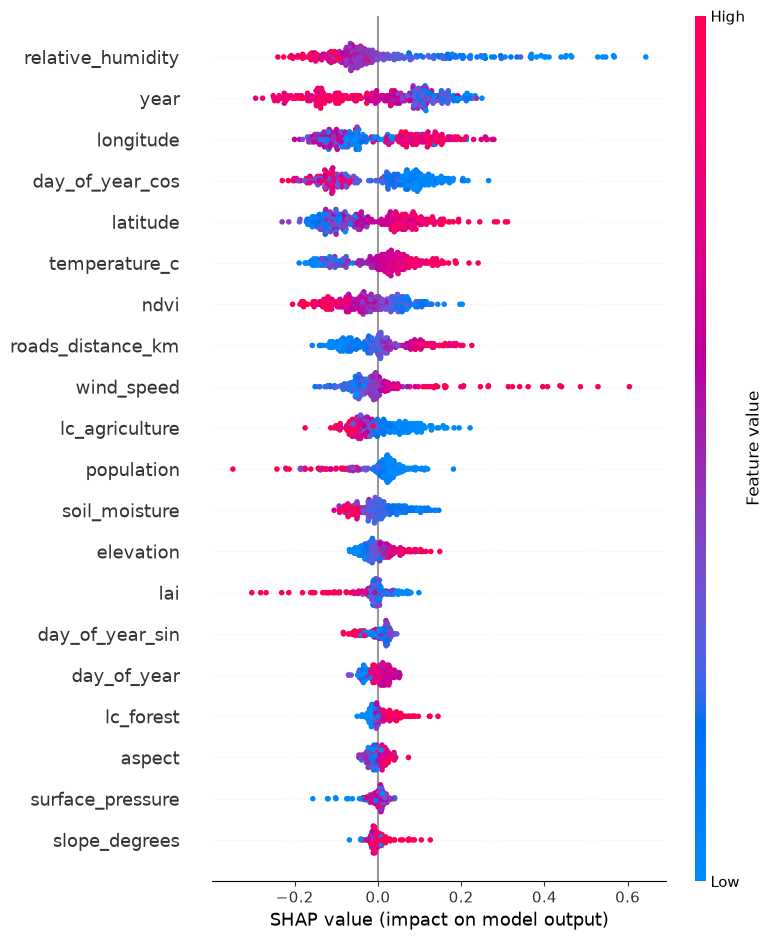

In [27]:
# SHAP GLOBAL SUMMARY

shap.summary_plot(
    shap_values,
    X_shap,
    max_display=20
)

## SHAP Global Explainability

SHAP (SHapley Additive exPlanations) was used to provide a global
interpretation of the final 70:30 HistGradientBoosting–Random Forest
ensemble. SHAP values were calculated for a representative sample of
300 testing observations across the 44 input features.

The SHAP summary indicates that **relative humidity** has the greatest
overall influence on model predictions. Lower relative-humidity values
generally produce positive SHAP contributions, increasing the predicted
logarithm of burned area, while higher humidity values tend to produce
negative contributions.

The **year** variable is the second most influential feature, indicating
that the model captures substantial year-to-year variation in the
dataset. Geographic variables, particularly **longitude and latitude**,
also have strong contributions, demonstrating that the model captures
spatial patterns associated with wildfire behaviour.

The cyclical variable **day_of_year_cos** is another important predictor,
confirming that seasonal patterns contribute to burned-area estimation.
Meteorological variables such as **temperature and wind speed** also
have meaningful effects, with higher wind-speed and temperature values
generally producing positive contributions to the model output.

Vegetation and land-cover variables, including **NDVI and agricultural
land cover**, also contribute to predictions. Higher NDVI values tend
to produce more negative SHAP contributions in the observed data,
whereas lower NDVI values are more frequently associated with positive
contributions.

Overall, the SHAP analysis demonstrates that the final model combines
meteorological, geographical, temporal, vegetation and land-cover
information rather than relying on a single predictor. The SHAP results
are also broadly consistent with the permutation feature importance
analysis, strengthening confidence in the identified influential
features.

The SHAP values describe the behaviour learned by the predictive model
and should therefore be interpreted as predictive associations rather
than direct causal relationships.

In [28]:
# SHAP INDIVIDUAL PREDICTION

# Select one representative test observation
observation_index = 0

X_one = X_test.iloc[[observation_index]]

actual_log = y_test.iloc[observation_index]

predicted_log = final_ensemble_predict(X_one)[0]

print("Individual SHAP Analysis")
print("=" * 50)

print("Test observation:", observation_index)
print("Actual log burned area:", round(actual_log, 4))
print("Predicted log burned area:", round(predicted_log, 4))

# Convert back to hectares
actual_ha = np.expm1(actual_log)
predicted_ha = np.expm1(predicted_log)

print("Actual burned area (ha):", round(actual_ha, 2))
print("Predicted burned area (ha):", round(predicted_ha, 2))

Individual SHAP Analysis
Test observation: 0
Actual log burned area: 4.5218
Predicted log burned area: 4.6543
Actual burned area (ha): 91.0
Predicted burned area (ha): 104.04


In [29]:
# SHAP VALUES FOR INDIVIDUAL OBSERVATION

shap_one = explainer(X_one)

print("Individual SHAP values calculated.")

Individual SHAP values calculated.


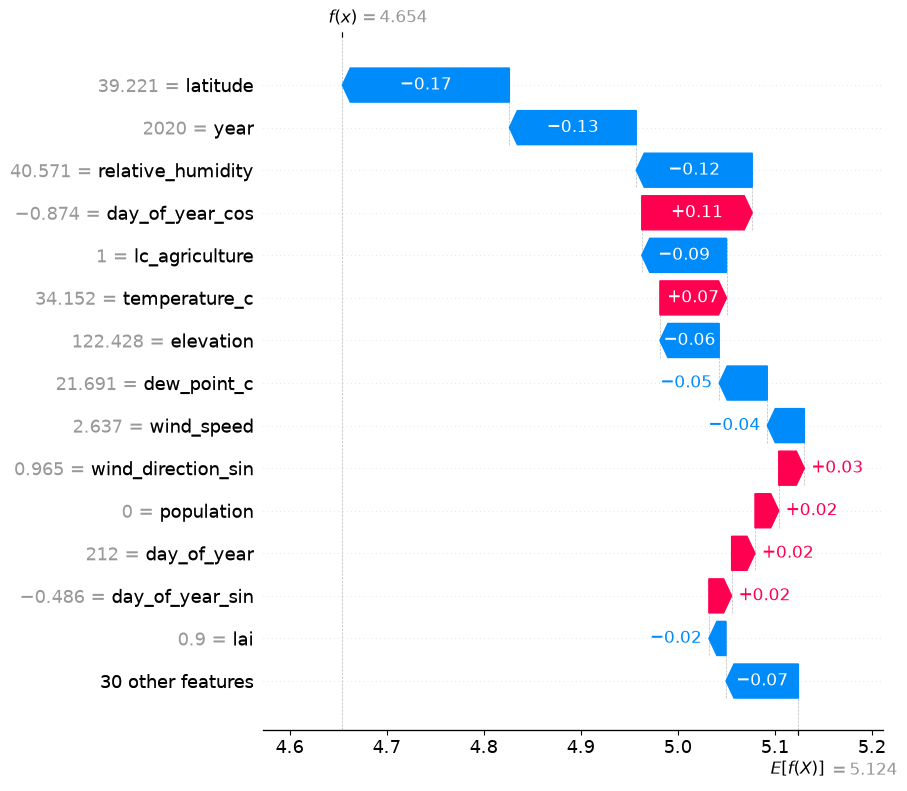

In [30]:
# SHAP WATERFALL PLOT

shap.plots.waterfall(
    shap_one[0],
    max_display=15
)

In [31]:
# INDIVIDUAL SHAP EXPLANATION TABLE

individual_shap_df = pd.DataFrame({
    "Feature": X_one.columns,
    "Feature_Value": X_one.iloc[0].values,
    "SHAP_Value": shap_one.values[0],
})

individual_shap_df["Absolute_SHAP"] = (
    individual_shap_df["SHAP_Value"].abs()
)

individual_shap_df["Effect"] = np.where(
    individual_shap_df["SHAP_Value"] > 0,
    "Increases prediction",
    "Decreases prediction"
)

individual_shap_df = (
    individual_shap_df
    .sort_values("Absolute_SHAP", ascending=False)
    .reset_index(drop=True)
)

display(
    individual_shap_df.head(15).round(4)
)

,Feature,Feature_Value,SHAP_Value,Absolute_SHAP,Effect
0,latitude,39.2212,-0.1721,0.1721,Decreases prediction
1,year,2020.0000,-0.1307,0.1307,Decreases prediction
2,relative_humidity,40.5712,-0.1195,0.1195,Decreases prediction
3,day_of_year_cos,-0.8738,0.1139,0.1139,Increases prediction
4,lc_agriculture,1.0000,-0.0874,0.0874,Decreases prediction
5,temperature_c,34.1516,0.0687,0.0687,Increases prediction
6,elevation,122.4282,-0.0611,0.0611,Decreases prediction
7,dew_point_c,21.6911,-0.0495,0.0495,Decreases prediction
8,wind_speed,2.6369,-0.0382,0.0382,Decreases prediction
9,wind_direction_sin,0.9645,0.0264,0.0264,Increases prediction


In [32]:
# TOP POSITIVE AND NEGATIVE CONTRIBUTORS

positive_contributors = (
    individual_shap_df[
        individual_shap_df["SHAP_Value"] > 0
    ]
    .head(5)
)

negative_contributors = (
    individual_shap_df[
        individual_shap_df["SHAP_Value"] < 0
    ]
    .head(5)
)

print("TOP FEATURES INCREASING THE PREDICTION")
print("=" * 50)

display(
    positive_contributors.round(4)
)

print("\nTOP FEATURES DECREASING THE PREDICTION")
print("=" * 50)

display(
    negative_contributors.round(4)
)

TOP FEATURES INCREASING THE PREDICTION


,Feature,Feature_Value,SHAP_Value,Absolute_SHAP,Effect
3,day_of_year_cos,-0.8738,0.1139,0.1139,Increases prediction
5,temperature_c,34.1516,0.0687,0.0687,Increases prediction
9,wind_direction_sin,0.9645,0.0264,0.0264,Increases prediction
10,population,0.0000,0.0245,0.0245,Increases prediction
11,day_of_year,212.0000,0.0241,0.0241,Increases prediction



TOP FEATURES DECREASING THE PREDICTION


,Feature,Feature_Value,SHAP_Value,Absolute_SHAP,Effect
0,latitude,39.2212,-0.1721,0.1721,Decreases prediction
1,year,2020.0000,-0.1307,0.1307,Decreases prediction
2,relative_humidity,40.5712,-0.1195,0.1195,Decreases prediction
4,lc_agriculture,1.0000,-0.0874,0.0874,Decreases prediction
6,elevation,122.4282,-0.0611,0.0611,Decreases prediction


## Individual Prediction Explainability

An individual SHAP analysis was performed to demonstrate how the final
ensemble generates an individual burned-area prediction.

For the selected test observation, the actual burned area was **91.00 ha**
while the model predicted **104.04 ha**. The corresponding log-transformed
values were 4.5218 and 4.6543 respectively, indicating a relatively small
prediction difference for this observation.

The strongest factors decreasing the prediction were **latitude**
(SHAP = -0.1721), **year** (-0.1307), **relative humidity** (-0.1195),
**agricultural land cover** (-0.0874), and **elevation** (-0.0611).

Conversely, **day_of_year_cos** (+0.1139) and **temperature**
(+0.0687) were the strongest contributors increasing the prediction,
with smaller positive contributions from wind direction, population
and day of year.

The SHAP waterfall plot demonstrates how these individual feature
contributions combine with the model's baseline prediction to produce
the final predicted value. This provides a transparent explanation of
an individual prediction rather than treating the model as a black box.

The analysis demonstrates that the final system can provide both a
numerical burned-area estimate and an interpretable explanation of the
factors influencing that estimate.